In [1]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [2]:
import src.data_handler.data_loader as load_module
reload(load_module)
load_data = load_module.load_data

In [3]:
# data = load_data(r"./dummy_data/testing_0")

data = load_data(
    r"./dummy_data/tree",
    colnames = {
        'id': 'track_id',
        't': 'time_point',
        'x': 'x_coordinate',
        'y': 'y_coordinate'
    },
)

C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\data_handler\df_metadata_manager.py:176: InputWarning: No time units found in input files.
 Please specify the time units using <load_data result>.metadata.write(time_unit="<unit>")
  self._check()
C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\data_handler\df_metadata_manager.py:176: InputWarning: No spatial units found in input files.
 Please specify the spatial units using <load_data result>.metadata.write(spatial_unit="<unit>")
  self._check()


In [4]:
data.metadata.write(spatialunits='um', timeunits='s')
data.metadata.get()

{'timeunits': 's',
 'spatialunits': 'μm',
 'nframes': 97,
 'timeinterval': 1.0,
 'columns': ['track_id',
  'time_point',
  'x_coordinate',
  'y_coordinate',
  'track_uid']}

In [5]:
import src.object_interface as object_module
reload(object_module)
create_object = object_module.create_object

data_object = create_object(data)

In [6]:
data_object.compute_tracks()

subsubgroup,subgroup,group,subset,set,track_uid,speed_min,speed_max,speed_mean,speed_sd,speed_median,track_length,x_location,y_location,max_distance_reached,track_start_frame,track_end_frame,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_points,track_displacement,straightness_ratio,track_id
str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""dummy_cell_tracks_0.csv""","""rep1""","""ctrl""","""subset_1""","""set_A""",0,3.591576,10.083021,7.122052,1.434158,7.24023,683.717025,664.908116,427.664523,635.975121,0,96,6.556445,0.920584,0.593897,0.074016,11.20775,0.115544,97,635.975121,0.930173,1.0
"""dummy_cell_tracks_1.csv""","""rep1""","""ctrl""","""subset_1""","""set_A""",1,1.601607,5.525199,3.410214,0.79065,3.486127,327.380517,469.917521,62.620486,121.040424,0,96,0.706997,0.207318,0.735197,0.777672,33.862342,0.349096,97,68.578722,0.209477,2.0
"""dummy_cell_tracks_2.csv""","""rep1""","""ctrl""","""subset_1""","""set_A""",2,0.254408,3.561361,2.080716,0.648953,2.057925,199.748745,380.910658,450.036984,96.18316,0,96,0.41464,0.199278,0.698432,0.796027,19.860154,0.204744,97,40.220094,0.201353,3.0
"""dummy_cell_tracks_0.csv""","""rep2""","""ctrl""","""subset_1""","""set_A""",3,0.795407,5.428437,3.146842,0.858003,3.090928,302.096856,111.726479,410.326022,231.100112,0,96,2.382475,0.7571,1.615627,0.245959,16.981645,0.175069,97,231.100112,0.764987,4.0
"""dummy_cell_tracks_1.csv""","""rep2""","""ctrl""","""subset_1""","""set_A""",4,1.50988,4.682856,2.772487,0.639068,2.737676,266.158763,305.17542,424.713323,167.728955,0,96,1.729164,0.623687,2.771445,0.388285,23.445117,0.241702,97,167.728955,0.630184,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dummy_cell_tracks_1.csv""","""rep1""","""treated""","""subset_2""","""set_B""",43,3.736858,9.601766,6.397749,1.40604,6.237907,614.183909,386.02585,71.031025,183.762928,0,96,1.894463,0.296114,-0.028988,0.703242,28.575522,0.294593,97,183.762928,0.299199,44.0
"""dummy_cell_tracks_2.csv""","""rep1""","""treated""","""subset_2""","""set_B""",44,2.77478,7.367298,4.996093,1.090322,5.047387,479.624937,85.743604,212.965355,181.990498,0,96,0.847456,0.169624,0.828144,0.820604,23.68532,0.244179,97,82.20319,0.171391,45.0
"""dummy_cell_tracks_0.csv""","""rep2""","""treated""","""subset_2""","""set_B""",45,2.782205,8.206474,5.683312,1.238897,5.737695,545.597949,347.709523,222.114156,225.928538,0,96,2.32916,0.409824,-0.595724,0.588716,27.98728,0.288529,97,225.928538,0.414093,46.0


AttributeError: 'NoneType' object has no attribute 'get'

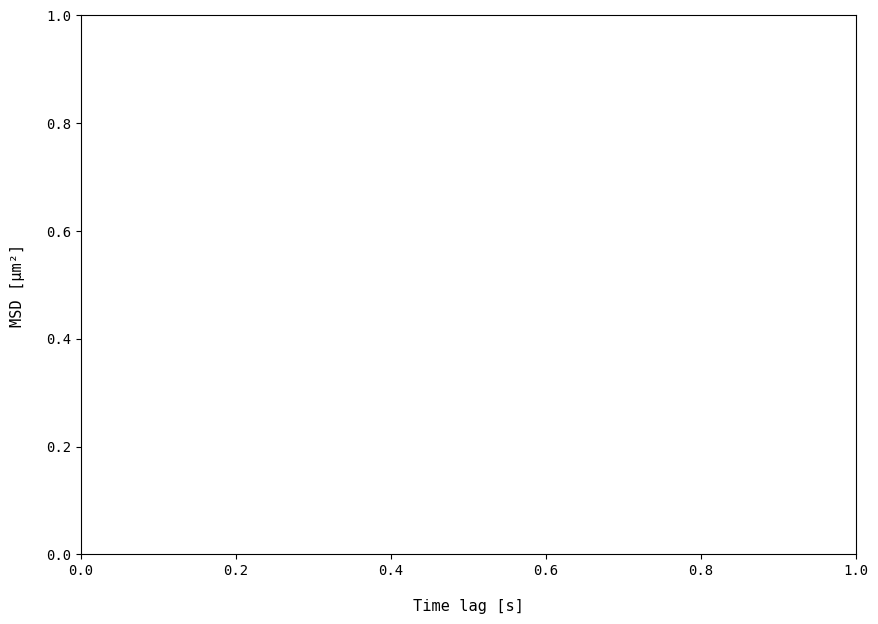

In [7]:
data_object.plot_msd(grouping_level = 'group', grid = True)

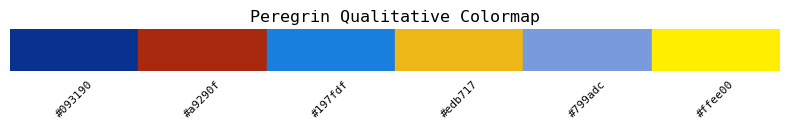

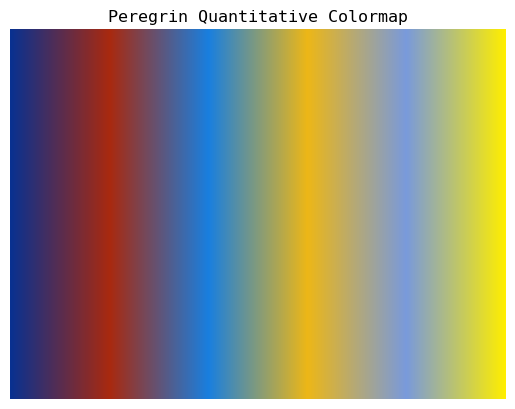

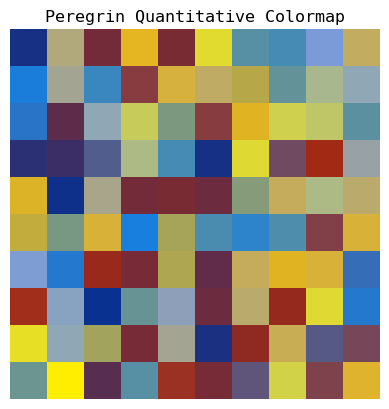

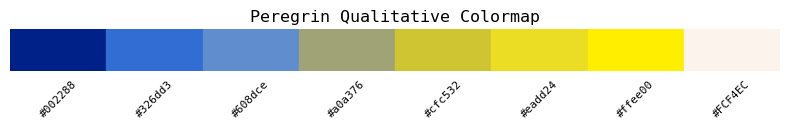

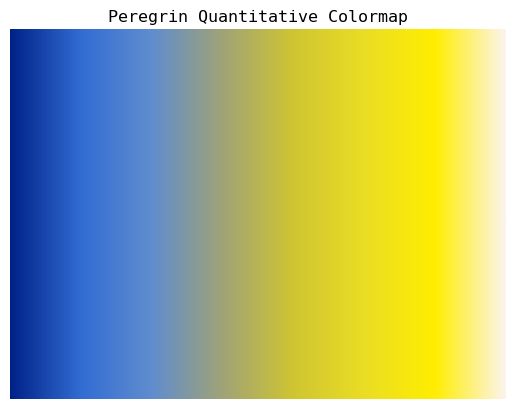

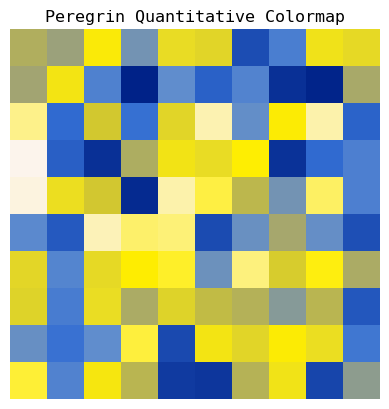

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

peregrin_cmap2 = ['#002288', "#326dd3", '#608dce', '#a0a376', '#cfc532', '#eadd24', '#ffee00', "#FCF4EC"]
peregrin_cmap1 = ['#093190', "#a9290f", '#197fdf', '#edb717', '#799adc',  '#ffee00']

def peregrin_cmap_func(peregrin_cmap):

    fig, ax = plt.subplots(figsize=(8, 1.5))
    n = len(peregrin_cmap)
    for i, color in enumerate(peregrin_cmap):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, -0.15, color, ha='center', va='top', fontsize=8, rotation=45)

    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title("Peregrin Qualitative Colormap")
    plt.tight_layout()
    plt.show()

    quantitative_cmap = mcolors.LinearSegmentedColormap.from_list("_peregrin", peregrin_cmap)
    plt.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()

    plt.imshow(np.array(np.repeat(np.random.rand(10, 10), 1, axis=0)), cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()


for cmap in [peregrin_cmap1, peregrin_cmap2]:
    peregrin_cmap_func(cmap)